# OvisOCR2 vs PaddleOCR-VL 1.6 — end-to-end benchmark

One notebook, run top-to-bottom, produces the full comparison of **OvisOCR2** (run here on a
Modal **L4** GPU) against the **PaddleOCR-VL 1.6** results already in this repo — with tables,
metrics, and figures rendered in the output cells **and** saved under `results/`.

**Pipeline**

| § | Step | Needs GPU / API? |
|---|---|---|
| 0–1 | Install, load `.env`, config | no |
| 2–4 | Run OvisOCR2 on the 100 images on an **L4** (Modal) → `.md` + `.html` + manifest | **Modal L4** |
| 5 | Preview one page (source image + rendered HTML) | no |
| 6 | **Layer 3** — divergence vs VL 1.6 (finds pages to review; not a winner call) | no |
| 7 | **Layer 1** — operational + robustness + completeness (latency, failure flags) | no |
| 8 | **Layer 2** — quality verdict via **Gemini 3.5 Flash** LLM-judge, with thinking (the winner call) | **Vertex AI** |
| 9 | Results — win-rate, per-category, sub-scores, figures, recommendation | no |

**Auth:** Modal via `modal token new` (once); the Gemini judge (§8) runs on **Vertex AI** using the
service-account file `vertex-service-account.json` in the repo root — no API key needed.

## 0. Install

In [ ]:
%pip install -q "modal>=1.0" google-genai python-dotenv markdown pandas matplotlib pillow

## 1. Config & auth

Loads `.env` (picks up `GOOGLE_API_KEY`), sets paths, and gathers the 100 images.
`MAX_IMAGES = None` runs the full set — set an int for a quick smoke test.

In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv, find_dotenv
import matplotlib.pyplot as plt
%matplotlib inline

load_dotenv(find_dotenv(usecwd=True))     # picks up ../.env (unused by the §8 judge, which uses Vertex)

# --- model / infra ---
MODEL_ID       = "ATH-MaaS/OvisOCR2"
GPU            = "L4"
GEMINI_MODEL   = "gemini-3.5-flash"        # §8 judge; runs on Vertex AI (service-account auth)
VL_AVG_LATENCY = 24.432                    # PaddleOCR-VL 1.6, from results/resource_summary.csv

# --- paths (relative to this notebook in experiments/ovisocr2_vs_vl/) ---
DATA_DIR = Path("../../data/test_dataset_100")                                    # the 100 images
VL_DIR   = Path("../100img_run4_sv3_ocrv6_lean/results/vl_1_6")    # existing VL 1.6 outputs
OUT_ROOT = Path("results")
OUT_DIR  = OUT_ROOT / "ovisocr2_html"
MD_DIR   = OUT_ROOT / "ovisocr2_md"
FIG_DIR  = OUT_ROOT / "figures"
MANIFEST = OUT_ROOT / "ovisocr2_per_image.csv"
JUDGE_CSV = OUT_ROOT / "judge_ovis_vs_vl_gemini35.csv"   # §8 overrides this; kept in sync here

EXTS       = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff", ".tif", ".jfif"}
MAX_IMAGES = None       # None = all 100; set an int (e.g. 5) for a smoke test
CHUNK      = 25         # images per remote call to the L4

CATEGORIES = ("agenda", "form", "invoice", "report", "original")
def category_of(stem):
    for c in CATEGORIES:
        if stem.lower().startswith(c):
            return c
    return "other"

for d in (OUT_DIR, MD_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

image_paths = sorted(p for p in DATA_DIR.rglob("*") if p.suffix.lower() in EXTS)
if MAX_IMAGES:
    image_paths = image_paths[:MAX_IMAGES]

_cred = (Path("../..") / "vertex-service-account.json").resolve()
print(f"Images     : {len(image_paths)} under {DATA_DIR}"
      + (f"  (MAX_IMAGES={MAX_IMAGES})" if MAX_IMAGES else ""))
print(f"VL 1.6 dir : {VL_DIR}  ({len(list(VL_DIR.glob('*.md')))} .md pages)")
print(f"Vertex cred: {'FOUND' if _cred.exists() else 'MISSING — ' + str(_cred)}")
print(f"Outputs -> {OUT_ROOT.resolve()}")
assert image_paths, f"No images under {DATA_DIR.resolve()} — check DATA_DIR."

Images     : 100 under ../../data/test_dataset_100
VL 1.6 dir : ../100img_run4_sv3_ocrv6_lean/results/vl_1_6  (100 .md pages)
Vertex cred: FOUND
Outputs -> /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_vl/results


## 2. The OvisOCR2 model on an L4 (Modal)

The Modal app lives in the sidecar module **`ovisocr2_modal_app.py`** next to this notebook
(a class defined *inside* a notebook can't be shipped to Modal across Python versions, so it lives
in a module). It pins vLLM 0.22.1, caches the weights in a Modal Volume, and disables the FlashInfer
sampler (the slim image has no `nvcc` to JIT-compile it).

In [2]:
# The Modal app lives in a sidecar module (ovisocr2_modal_app.py) next to this notebook.
# Why a module and not inline: a class defined *in* a notebook is shipped to Modal via
# cloudpickle, which requires your local Python to match the container's (3.11). Importing
# it from a module skips that, so this notebook runs under any local Python (e.g. 3.9).
import modal
from ovisocr2_modal_app import app, OvisOCR2, MODEL_ID as APP_MODEL_ID, GPU as APP_GPU

print("Modal app:", app.name)
print("Model:", APP_MODEL_ID, "| GPU:", APP_GPU)
# Edit knobs (enforce_eager, gpu_memory_utilization, model id) in ovisocr2_modal_app.py,
# then re-run this cell to pick up the changes.

Modal app: ovisocr2-l4-image-to-html
Model: ATH-MaaS/OvisOCR2 | GPU: L4


## 3. Markdown → standalone HTML (local, no GPU)

OvisOCR2 emits Markdown with raw HTML tables + LaTeX; render it to a self-contained HTML page in the
same house style as the VL / StructureV3 pages.

In [3]:
import markdown as md_lib

HOUSE_CSS = (
    "body{font-family:Arial,Helvetica,sans-serif;max-width:900px;margin:24px auto;"
    "padding:0 16px;line-height:1.5}"
    "table{border-collapse:collapse;margin:12px 0}"
    "td,th{border:1px solid #888;padding:4px 8px;vertical-align:top}"
    "h1,h2,h3{margin:.6em 0 .3em}img{max-width:100%}"
)

MATHJAX = (
    "<script>window.MathJax={tex:{inlineMath:[['$','$'],['\\\\(','\\\\)']],"
    "displayMath:[['$$','$$'],['\\\\[','\\\\]']]}};</script>"
    "<script async src='https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js'></script>"
)


def md_to_html(markdown_text: str, title: str) -> str:
    body = md_lib.markdown(markdown_text, extensions=["tables", "fenced_code", "sane_lists"])
    return (
        "<!doctype html>\n<html><head><meta charset='utf-8'>"
        f"<title>{title}</title><style>{HOUSE_CSS}</style>{MATHJAX}</head>\n"
        f"<body>\n{body}\n</body></html>\n"
    )

## 4. Run OvisOCR2 on the 100 images (L4)

`app.run()` starts an ephemeral Modal app, sends the images to the L4 in chunks, and writes per image
a `.md`, a `.html`, and a manifest row (`latency, chars, n_tables`). The first chunk pays the cold
start (weight download once, then model load); later chunks hit the warm container.

In [4]:
import time, csv

FIELDS = ["model", "key", "image", "category", "latency",
          "regions", "chars", "mean_conf", "n_tables"]

def chunked(seq, n):
    for i in range(0, len(seq), n):
        yield seq[i:i + n]

# --- resumable: skip images that already have a .md; keep any known latencies ---
latmap = {}
if MANIFEST.exists():
    for r in csv.DictReader(open(MANIFEST)):
        if r.get("latency"):
            latmap[Path(r["image"]).stem] = r["latency"]

todo = [p for p in image_paths if not (MD_DIR / f"{p.stem}.md").exists()]
have = len(image_paths) - len(todo)
print(f"Already parsed on disk: {have}/{len(image_paths)}.  To parse now: {len(todo)}")

t0 = time.time()
if todo:
    with modal.enable_output(), app.run():
        ocr = OvisOCR2()
        n_done = 0
        for batch in chunked(todo, CHUNK):
            items = [(p.name, p.read_bytes()) for p in batch]
            for r in ocr.parse_batch.remote(items):
                stem = Path(r["image"]).stem
                (MD_DIR / f"{stem}.md").write_text(r["markdown"], encoding="utf-8")
                (OUT_DIR / f"{stem}.html").write_text(
                    md_to_html(r["markdown"], r["image"]), encoding="utf-8")
                latmap[stem] = r["latency"]        # remember real per-image latency
            n_done += len(batch)
            print(f"[{n_done}/{len(todo)}] chunk done  (total {have + n_done}/{len(image_paths)})")
else:
    print("Nothing to parse — all pages already on disk.")

# --- rebuild the manifest from everything on disk (idempotent; survives interruptions) ---
rows = []
for f in sorted(MD_DIR.glob("*.md")):
    stem = f.stem; md = f.read_text(encoding="utf-8")
    rows.append({"model": "OvisOCR2", "key": "ovisocr2", "image": f"{stem}.jpg",
                 "category": category_of(stem), "latency": latmap.get(stem, ""),
                 "regions": "", "chars": len(md), "mean_conf": "", "n_tables": md.lower().count("<table")})
with open(MANIFEST, "w", newline="") as fh:
    wr = csv.DictWriter(fh, fieldnames=FIELDS); wr.writeheader(); wr.writerows(rows)

lat = [float(r["latency"]) for r in rows if r["latency"]]
print(f"\nManifest: {len(rows)} pages -> {MANIFEST}")
if todo:
    print(f"This run: {len(todo)} pages in {time.time() - t0:.1f}s wall")
if lat:
    print(f"Mean model latency: {sum(lat) / len(lat):.2f}s/img (over {len(lat)} timed pages)")
else:
    print("No per-image latencies recorded (pages were parsed in an earlier, interrupted run). "
          "To get clean 100-page latency, delete ovisocr2_md/ and re-run this cell.")
print(f"HTML -> {OUT_DIR}\nMarkdown -> {MD_DIR}")

Already parsed on disk: 0/100.  To parse now: 100
✓ Initialized. View run at 
https://modal.com/apps/liberate-ai/main/ap-kZxlDRFTyf8O9P9YM7aClV
⠋ Initializing...
⠦ Creating objects...objects...
└── ⠋ Creating mount 
    /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_
⠏ Creating objects...
└── ⠸ Creating mount 
    /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_
⠹ Creating objects... 1 files
└── 🔨 Created mount 
    /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_
⠴ Creating objects...
├── 🔨 Created mount 
│   /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_
│   vl/ovisocr2_modal_app.py
⠏ Creating objects...
├── 🔨 Created mount 
│   /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_
│   vl/ovisocr2_modal_app.py
⠹ Creating objects...
├── 🔨 Created mount 
│   /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_
│   vl/ovisocr2_

## 5. Preview one page — source image + OvisOCR2 HTML

Source image: agenda_01.jpg


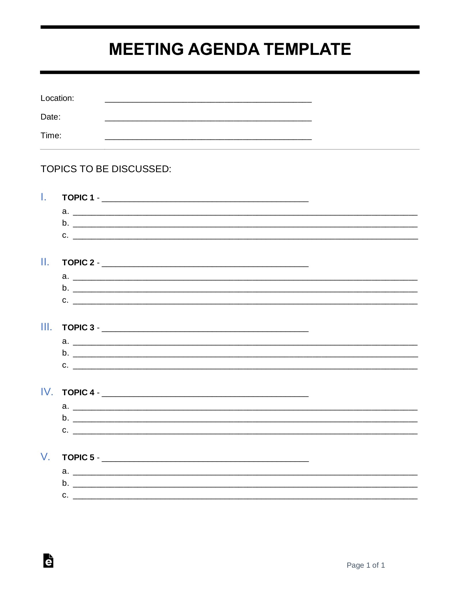


OvisOCR2 rendered HTML:


In [5]:
from IPython.display import HTML, display
from PIL import Image as PILImage

if image_paths:
    p = image_paths[0]
    im = PILImage.open(p).convert("RGB")
    w = 460
    print("Source image:", p.name)
    display(im.resize((w, int(w * im.height / im.width))))
    print("\nOvisOCR2 rendered HTML:")
    display(HTML((OUT_DIR / f"{p.stem}.html").read_text(encoding="utf-8")))

## 6. Layer 3 — divergence vs VL 1.6

Reuses the **identical** metric functions as `ocr_vl16_comparison.ipynb`, so numbers line up with
run1–run4. **This measures how much OvisOCR2 *diverges* from VL — it does NOT pick a winner** (with
VL as the pseudo-reference, VL scores 1.0 by construction). Use it to rank the pages that disagree
most, which is where the §8 judge / your eyes matter.

Scored 100 pages vs VL 1.6  ->  results/quality_vs_vl_ovisocr2_per_image.csv


,mean vs VL
word_P,0.834
word_R,0.924
word_F1,0.857
char_sim,0.780
table_recall,0.920


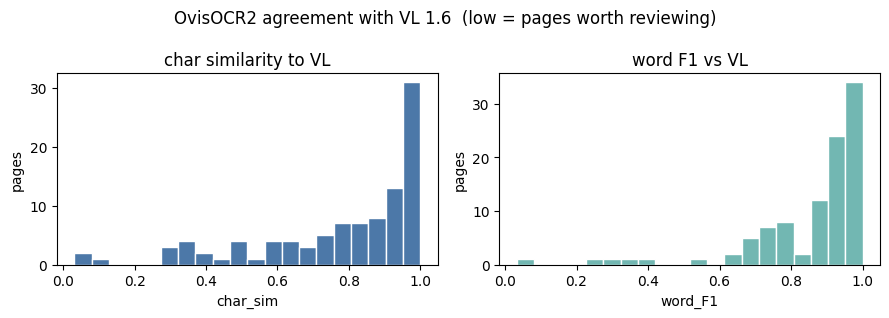

Most-divergent pages (lowest char similarity):


,image,category,char_sim,word_F1,model_tables,vl_tables
28,form_06.jpg,form,0.030648,0.032787,1,1
44,form_22.jpg,form,0.062411,0.232877,0,1
88,report_09.jpg,report,0.111961,0.667479,1,3
60,invoice_15.jpg,invoice,0.300589,0.941176,4,2
87,report_08.jpg,report,0.315407,0.925764,2,2
38,form_16.jpg,form,0.319050,0.314607,0,0
56,invoice_11.jpg,invoice,0.335303,0.980000,2,3
73,original_005.jpg,original,0.346647,0.724771,0,0


In [6]:
import os, re, html, glob, difflib
from collections import Counter
import pandas as pd

OUT_CSV = OUT_ROOT / "quality_vs_vl_ovisocr2_per_image.csv"
_TAG = re.compile(r"<[^>]+>"); _MD = re.compile(r"[#*_`|>]+"); _WS = re.compile(r"\s+")

def normtext(s):
    s = _TAG.sub(" ", s or ""); s = html.unescape(s); s = _MD.sub(" ", s)
    s = s.replace("-", " "); s = _WS.sub(" ", s).lower().strip()
    return s
def char_sim(a, b): return difflib.SequenceMatcher(None, a, b).ratio()
def word_prf(pred, ref):
    p, r = Counter(pred.split()), Counter(ref.split()); inter = sum((p & r).values())
    P = inter / max(sum(p.values()), 1); R = inter / max(sum(r.values()), 1)
    return P, R, 2 * P * R / max(P + R, 1e-9)
def n_tables(md_): return md_.lower().count("<table")

vl = {}
for f in glob.glob(os.path.join(str(VL_DIR), "*.md")):
    stem = os.path.splitext(os.path.basename(f))[0]; raw = open(f, encoding="utf-8").read()
    vl[stem] = {"text": normtext(raw), "tables": n_tables(raw)}
assert vl, f"No VL 1.6 .md under {VL_DIR}"

rows = []
for f in sorted(glob.glob(os.path.join(str(MD_DIR), "*.md"))):
    stem = os.path.splitext(os.path.basename(f))[0]
    if stem not in vl: continue
    raw = open(f, encoding="utf-8").read(); pred, ref = normtext(raw), vl[stem]["text"]
    P, R, F = word_prf(pred, ref); vt, mt = vl[stem]["tables"], n_tables(raw)
    rows.append({"image": f"{stem}.jpg", "category": category_of(stem),
                 "word_P": P, "word_R": R, "word_F1": F, "char_sim": char_sim(pred, ref),
                 "vl_tables": vt, "model_tables": mt,
                 "table_recall": (min(mt, vt) / vt) if vt > 0 else float("nan")})

dfq = pd.DataFrame(rows); dfq.to_csv(OUT_CSV, index=False)
print(f"Scored {len(dfq)} pages vs VL 1.6  ->  {OUT_CSV}")
display(dfq[["word_P", "word_R", "word_F1", "char_sim", "table_recall"]].mean().round(3).to_frame("mean vs VL"))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(dfq["char_sim"], bins=20, color="#4C78A8", edgecolor="white"); ax[0].set_title("char similarity to VL"); ax[0].set_xlabel("char_sim")
ax[1].hist(dfq["word_F1"].dropna(), bins=20, color="#72B7B2", edgecolor="white"); ax[1].set_title("word F1 vs VL"); ax[1].set_xlabel("word_F1")
for a in ax: a.set_ylabel("pages")
fig.suptitle("OvisOCR2 agreement with VL 1.6  (low = pages worth reviewing)")
fig.tight_layout(); fig.savefig(FIG_DIR / "divergence_vs_vl.png", dpi=150, bbox_inches="tight"); plt.show()

print("Most-divergent pages (lowest char similarity):")
display(dfq.sort_values("char_sim").head(8)[["image", "category", "char_sim", "word_F1", "model_tables", "vl_tables"]])

## 7. Layer 1 — operational + robustness + completeness

Automatic, no labels. Latency (OvisOCR2 real per-image vs VL benchmark average), robustness flags
(empty / degenerate repetition / unbalanced `<table>` HTML), and completeness (chars, tables). Flags
the OvisOCR2 pages that look broken.

,pages,avg_latency_s,avg_chars,avg_tables,pct_empty,pct_degenerate,pct_bad_table
model,,,,,,,
OvisOCR2,100,30.27,1621,1.53,0.0,9.0,0.0
PaddleOCR-VL 1.6,100,24.43,4411,1.34,1.0,4.0,0.0


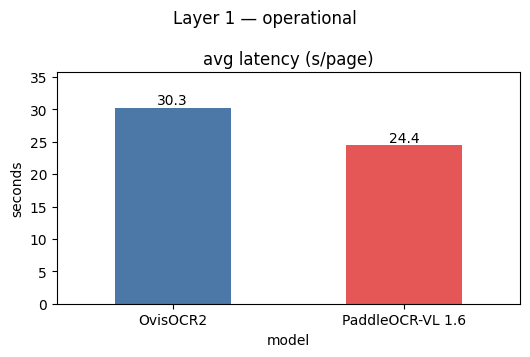

OvisOCR2 pages flagged broken (empty / degenerate / unbalanced-table): 9
['agenda_10.jpg', 'agenda_21.jpg', 'form_12.jpg', 'form_19.jpg', 'invoice_02.jpg', 'invoice_03.jpg', 'invoice_18.jpg', 'report_05.jpg', 'report_09.jpg']


In [7]:
import csv, glob, os
import statistics as st
from collections import Counter
import pandas as pd

def _empty(m): return len(m.strip()) < 20
def _bad(m):   return m.lower().count("<table") != m.lower().count("</table")
def _degen(m, thr=6):
    L = [x.strip() for x in m.splitlines() if x.strip()]
    return bool(L) and len(L) > thr and Counter(L).most_common(1)[0][1] >= thr
def _nt(m):    return m.lower().count("<table")

ovis = list(csv.DictReader(open(MANIFEST)))
for r in ovis:
    m = (MD_DIR / f"{os.path.splitext(r['image'])[0]}.md").read_text(encoding="utf-8")
    r["latency"] = float(r["latency"]) if r["latency"] not in ("", None) else None   # blank = untimed
    r["chars"] = int(r["chars"]); r["n_tables"] = int(r["n_tables"])
    r["empty"], r["degenerate"], r["bad_table_html"] = _empty(m), _degen(m), _bad(m)

vlr = []
for f in sorted(glob.glob(os.path.join(str(VL_DIR), "*.md"))):
    m = open(f, encoding="utf-8").read()
    vlr.append({"chars": len(m), "n_tables": _nt(m), "empty": _empty(m),
                "degenerate": _degen(m), "bad_table_html": _bad(m)})

# OvisOCR2 latency = mean over pages actually timed (blank = parsed in an earlier interrupted run)
timed = [r["latency"] for r in ovis if r["latency"] is not None]
ovis_lat = st.mean(timed) if timed else float("nan")
if 0 < len(timed) < len(ovis):
    print(f"note: latency averaged over {len(timed)}/{len(ovis)} timed pages "
          "(delete ovisocr2_md/ and re-run §4 to time all 100).")

def summ(rows, name, lat):
    pct = lambda k: round(100 * sum(1 for r in rows if r[k]) / max(len(rows), 1), 1)
    ok  = lat == lat   # False only for NaN
    return {"model": name, "pages": len(rows),
            "avg_latency_s": round(lat, 2) if ok else float("nan"),
            "avg_chars": round(st.mean(r["chars"] for r in rows)),
            "avg_tables": round(st.mean(r["n_tables"] for r in rows), 2),
            "pct_empty": pct("empty"), "pct_degenerate": pct("degenerate"), "pct_bad_table": pct("bad_table_html")}

dfop = pd.DataFrame([summ(ovis, "OvisOCR2", ovis_lat),
                     summ(vlr, "PaddleOCR-VL 1.6", VL_AVG_LATENCY)]).set_index("model")
dfop.to_csv(OUT_ROOT / "operational_summary.csv")
display(dfop)

fig, ax = plt.subplots(figsize=(5.4, 3.6))
dfop["avg_latency_s"].plot.bar(ax=ax, color=["#4C78A8", "#E45756"], rot=0)
ax.set_title("avg latency (s/page)"); ax.set_ylabel("seconds")
_top = dfop["avg_latency_s"].max()
ax.set_ylim(0, (_top * 1.18) if _top == _top else 1)   # headroom so value labels don't clip the frame
for i, val in enumerate(dfop["avg_latency_s"]):
    if val == val: ax.text(i, val, f"{val:.1f}", ha="center", va="bottom")
fig.suptitle("Layer 1 — operational"); fig.tight_layout()
fig.savefig(FIG_DIR / "operational.png", dpi=150, bbox_inches="tight"); plt.show()

flagged = [r["image"] for r in ovis if r["empty"] or r["degenerate"] or r["bad_table_html"]]
print(f"OvisOCR2 pages flagged broken (empty / degenerate / unbalanced-table): {len(flagged)}")
print(flagged[:20])

## 8. Layer 2 — quality verdict via Gemini 3.5 Flash (the winner call)

The independent signal §6 can't give: a vision model sees the **source image** + both transcriptions
and picks the more faithful one. It runs on **Vertex AI** (service-account auth via
`vertex-service-account.json`, project `bullseye-475215`) with **thinking enabled**, so the judge
reasons before committing to a verdict. Position-bias is randomized per page (seeded by filename) then
mapped back; verdicts + 1–5 sub-scores are written to `judge_ovis_vs_vl_gemini35.csv` (a fresh,
model-tagged file, so the old 2.5 verdicts are kept and all 100 pages are re-judged). **Resumable**
within that file. Skim a few `reason` values against the images before trusting the aggregate.

In [8]:
# ==== §8  LLM-judge via Gemini 3.5 Flash on Vertex AI (with thinking) ====
# Auth: Vertex AI service account (vertex-service-account.json) — NOT an API key.
# Model: gemini-3.5-flash with an explicit thinking budget so it reasons before the verdict.
# Writes a fresh, model-tagged CSV; the resumable skip is per-file, so all pages are re-judged.
# NEEDS §2–4 to have produced results/ovisocr2_md/ first (nothing to judge otherwise). §9 reads JUDGE_CSV.
%pip install -q "google-genai>=1.0" google-auth
import os, csv, json, random
from pathlib import Path
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from typing import Literal

# --- Vertex AI config (service account) ---
GEMINI_MODEL    = "gemini-3.5-flash"
VERTEX_PROJECT  = "bullseye-475215"
VERTEX_LOCATION = "global"                 # Gemini 3.x is served on the global endpoint
THINKING_BUDGET = 4096                      # tokens the judge may spend reasoning; -1 = dynamic, 0 = off
JUDGE_CSV       = OUT_ROOT / "judge_ovis_vs_vl_gemini35.csv"   # fresh, model-tagged file
MEDIA = {".jpg": "image/jpeg", ".jpeg": "image/jpeg", ".png": "image/png", ".webp": "image/webp"}

# Point Application Default Credentials at the service-account JSON in the repo root.
_cred = (Path("../..") / "vertex-service-account.json").resolve()
assert _cred.exists(), f"Service account JSON not found at {_cred}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(_cred)
client = genai.Client(vertexai=True, project=VERTEX_PROJECT, location=VERTEX_LOCATION)

class Verdict(BaseModel):
    winner: Literal["A", "B", "tie"]
    # Scores are bounded 1-5 in the schema so the judge can't drift to a 0-100 scale (§9 assumes 1-5).
    text_fidelity_A: int = Field(ge=1, le=5)
    text_fidelity_B: int = Field(ge=1, le=5)
    table_structure_A: int = Field(ge=1, le=5)
    table_structure_B: int = Field(ge=1, le=5)
    reading_order_A: int = Field(ge=1, le=5)
    reading_order_B: int = Field(ge=1, le=5)
    reason: str

SYSTEM = (
    "You are a meticulous OCR-evaluation judge. You are shown a source document image and two "
    "independent transcriptions of it (A and B). Your job is to decide which transcription is more "
    "FAITHFUL to what is physically on the page. Read the image carefully, region by region, and "
    "compare each transcription against it — reward exact text, complete coverage, and correct table "
    "structure; penalize missed content, invented/hallucinated content, merged or split cells, and "
    "scrambled reading order. Ignore purely cosmetic markdown/formatting differences that do not "
    "change the information. Be strict and evidence-based; do not favor a transcription for being "
    "longer or more elaborate."
)

PROMPT = (
    "Grade the two transcriptions of the document image above.\n\n"
    "Score EACH transcription on an INTEGER scale of 1 to 5 (5 = matches the page exactly, "
    "3 = usable with notable errors, 1 = severely wrong) on three dimensions:\n"
    "  • text_fidelity  — are the words/numbers correct, with nothing missed or invented?\n"
    "  • table_structure — do rows, columns, and cell contents match the page's tables?\n"
    "  • reading_order   — is content in the same logical order as the page?\n"
    "Then pick the overall winner. Use 'tie' ONLY when the two are genuinely equivalent in faithfulness.\n"
    "Base every score on concrete differences you can point to in the image; state them in 'reason'.\n\n"
    "Transcription A:\n<A>\n{A}\n</A>\n\nTranscription B:\n<B>\n{B}\n</B>"
)

done = set()
if JUDGE_CSV.exists():
    done = {r["image"] for r in csv.DictReader(open(JUDGE_CSV))}
FIELDS = ["image", "category", "winner", "assign", "text_ovis", "text_vl",
          "table_ovis", "table_vl", "order_ovis", "order_vl", "reason"]
newfile = not JUDGE_CSV.exists()
fh = open(JUDGE_CSV, "a", newline=""); w = csv.DictWriter(fh, fieldnames=FIELDS)
if newfile:
    w.writeheader()

todo = [p for p in image_paths if p.name not in done
        and (MD_DIR / f"{p.stem}.md").exists() and (VL_DIR / f"{p.stem}.md").exists()]
if not todo and not done:
    print("Nothing to judge: no page has BOTH an OvisOCR2 .md (results/ovisocr2_md/) and a VL .md. "
          "Run §2–4 to generate the OvisOCR2 outputs first.")
print(f"Judging {len(todo)} pages ({len(done)} already done) with {GEMINI_MODEL} "
      f"[Vertex {VERTEX_PROJECT}, thinking_budget={THINKING_BUDGET}] -> {JUDGE_CSV.name}")

for i, p in enumerate(todo, 1):
    stem = p.stem
    ovis_md = (MD_DIR / f"{stem}.md").read_text(encoding="utf-8")
    vl_md   = (VL_DIR / f"{stem}.md").read_text(encoding="utf-8")
    ovis_is_A = random.Random(stem).random() < 0.5     # de-bias A/B slot, deterministic per page
    A, B = (ovis_md, vl_md) if ovis_is_A else (vl_md, ovis_md)
    media = MEDIA.get(p.suffix.lower(), "image/jpeg")
    try:
        resp = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=[types.Part.from_bytes(data=p.read_bytes(), mime_type=media),
                      PROMPT.format(A=A[:20000], B=B[:20000])],
            config=types.GenerateContentConfig(
                system_instruction=SYSTEM,
                thinking_config=types.ThinkingConfig(thinking_budget=THINKING_BUDGET),
                response_mime_type="application/json",
                response_schema=Verdict,
                temperature=0),
        )
        v = resp.parsed or Verdict(**json.loads(resp.text))
    except Exception as e:
        print(f"  {stem}: ERROR {e}")
        continue
    pick = lambda a, b: (a if ovis_is_A else b)
    winner = "tie" if v.winner == "tie" else ("ovis" if (v.winner == "A") == ovis_is_A else "vl")
    w.writerow({
        "image": p.name, "category": category_of(stem), "winner": winner,
        "assign": "ovis=A" if ovis_is_A else "ovis=B",
        "text_ovis": pick(v.text_fidelity_A, v.text_fidelity_B),
        "text_vl":   pick(v.text_fidelity_B, v.text_fidelity_A),
        "table_ovis": pick(v.table_structure_A, v.table_structure_B),
        "table_vl":   pick(v.table_structure_B, v.table_structure_A),
        "order_ovis": pick(v.reading_order_A, v.reading_order_B),
        "order_vl":   pick(v.reading_order_B, v.reading_order_A),
        "reason": v.reason.replace("\n", " "),
    })
    fh.flush()
    if i % 10 == 0 or i == len(todo):
        print(f"  {i}/{len(todo)}  {p.name} -> {winner}")

fh.close()
print("judge verdicts ->", JUDGE_CSV)

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


/Users/asikifthakerhamim/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/asikifthakerhamim/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/asikifthakerhamim/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgr

Judging 100 pages (0 already done) with gemini-3.5-flash [Vertex bullseye-475215, thinking_budget=4096] -> judge_ovis_vs_vl_gemini35.csv


  10/100  agenda_10.jpg -> ovis


  20/100  agenda_20.jpg -> ovis


...

  60/100  invoice_14.jpg -> ovis


  70/100  original_001.jpg -> ovis


  80/100  original_011.jpg -> vl


  90/100  report_10.jpg -> ovis


  100/100  report_20.jpg -> ovis
judge verdicts -> results/judge_ovis_vs_vl_gemini35.csv


## 9. Results — win-rate, per-category, sub-scores, decision

Aggregates the judge verdicts into figures + a recommendation. Quality (win-rate) is the primary gate
within a ±10-point band; ties fall through to Layer-1 (latency / robustness). All figures are
saved under `figures/` and a one-row `final_summary.csv` is written.

Judged 99 pages with gemini-3.5-flash. Sample verdicts:


,image,category,winner,assign,text_ovis,text_vl,table_ovis,table_vl,order_ovis,order_vl,reason
0,agenda_01.jpg,agenda,ovis,ovis=A,5,4,5,5,5,5,Transcription A is highly accurate. It correct...
1,agenda_02.jpg,agenda,ovis,ovis=B,5,4,5,5,5,5,Transcription B is more complete as it include...
2,agenda_03.jpg,agenda,ovis,ovis=A,5,4,5,4,5,5,Transcription A is cleaner and more accurate. ...
3,agenda_04.jpg,agenda,ovis,ovis=B,5,4,5,2,5,5,Transcription B is exceptionally accurate. It ...
4,agenda_05.jpg,agenda,vl,ovis=B,5,5,3,4,5,5,Transcription A is the winner because it corre...
5,agenda_06.jpg,agenda,ovis,ovis=A,5,2,5,2,5,3,Transcription A is exceptionally accurate. It ...
6,agenda_07.jpg,agenda,vl,ovis=B,4,5,5,5,5,5,Transcription A is more faithful because it re...
7,agenda_08.jpg,agenda,ovis,ovis=B,5,4,5,1,5,5,Transcription B is superior because it correct...



Win-rate over 99 pages:  OvisOCR2 77%  |  VL 1.6 21%  |  tie 2%


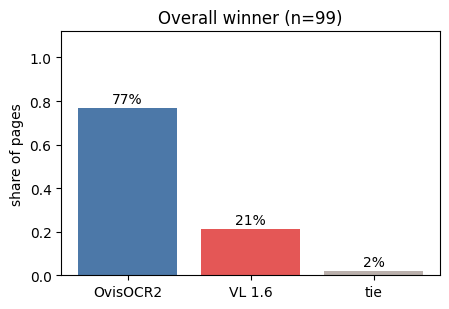

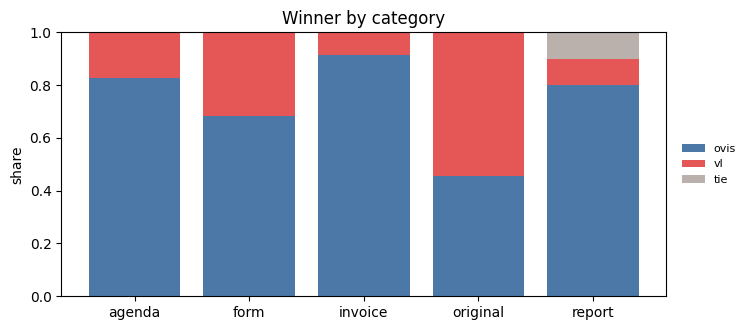

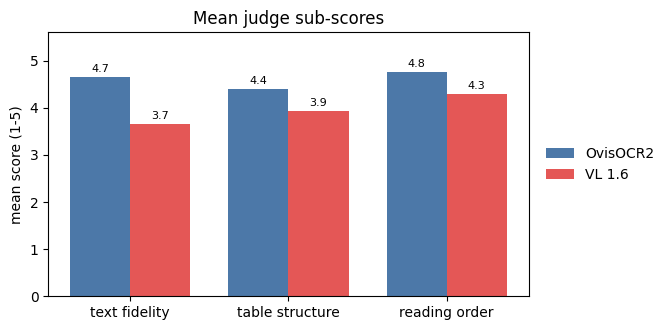

Win-rate by category:


,ovis,vl,tie
category,,,
agenda,83%,17%,0%
form,68%,32%,0%
invoice,91%,9%,0%
original,45%,55%,0%
report,80%,10%,10%



RECOMMENDATION (quality-primary, ±10% band):  OvisOCR2 (clear quality win)
Artifacts saved under /Users/asikifthakerhamim/Documents/image_ocr_sample/experiments/ovisocr2_vs_vl/results  (figures/, *.csv)


,value
pages,99
ovis_winrate,0.768
vl_winrate,0.212
tie_rate,0.02
text_ovis,4.66
text_vl,3.66
table_ovis,4.39
table_vl,3.93
order_ovis,4.77
order_vl,4.29


In [9]:
import pandas as pd, numpy as np
from collections import Counter

jdf = pd.read_csv(JUDGE_CSV)
assert len(jdf) > 0, "Run section 8 (the judge) first."
N = len(jdf)
print(f"Judged {N} pages with {GEMINI_MODEL}. Sample verdicts:")
display(jdf.head(8))

def wr(sub):
    c = Counter(sub["winner"]); t = len(sub) or 1
    return c.get("ovis", 0) / t, c.get("vl", 0) / t, c.get("tie", 0) / t

o, v, t = wr(jdf)
print(f"\nWin-rate over {N} pages:  OvisOCR2 {o:.0%}  |  VL 1.6 {v:.0%}  |  tie {t:.0%}")

# --- fig 1: overall win-rate ---
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.bar(["OvisOCR2", "VL 1.6", "tie"], [o, v, t], color=["#4C78A8", "#E45756", "#BAB0AC"])
for i, val in enumerate([o, v, t]): ax.text(i, val + 0.01, f"{val:.0%}", ha="center", va="bottom")
ax.set_ylim(0, 1.12); ax.set_ylabel("share of pages"); ax.set_title(f"Overall winner (n={N})")  # headroom for labels
fig.tight_layout(); fig.savefig(FIG_DIR / "winrate_overall.png", dpi=150, bbox_inches="tight"); plt.show()

# --- fig 2: per-category stacked (legend outside so it never overlaps the full-height bars) ---
cats = sorted(jdf["category"].unique())
D = {"ovis": [], "vl": [], "tie": []}
for c in cats:
    a, b, d = wr(jdf[jdf["category"] == c]); D["ovis"].append(a); D["vl"].append(b); D["tie"].append(d)
fig, ax = plt.subplots(figsize=(7.6, 3.4)); x = np.arange(len(cats)); bottom = np.zeros(len(cats))
for k, col in [("ovis", "#4C78A8"), ("vl", "#E45756"), ("tie", "#BAB0AC")]:
    ax.bar(x, D[k], bottom=bottom, label=k, color=col); bottom += np.array(D[k])
ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_ylim(0, 1); ax.set_ylabel("share")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
ax.set_title("Winner by category")
fig.tight_layout(); fig.savefig(FIG_DIR / "winrate_by_category.png", dpi=150, bbox_inches="tight"); plt.show()

# --- fig 3: mean sub-scores (legend outside; headroom so value labels don't clip at 5) ---
subs = ["text", "table", "order"]
ov  = [jdf[f"{s}_ovis"].mean() for s in subs]
vlm = [jdf[f"{s}_vl"].mean() for s in subs]
fig, ax = plt.subplots(figsize=(6.8, 3.4)); x = np.arange(3); wd = 0.38
ax.bar(x - wd / 2, ov, wd, label="OvisOCR2", color="#4C78A8")
ax.bar(x + wd / 2, vlm, wd, label="VL 1.6", color="#E45756")
ax.set_xticks(x); ax.set_xticklabels(["text fidelity", "table structure", "reading order"])
ax.set_ylim(0, 5.6); ax.set_ylabel("mean score (1-5)"); ax.set_title("Mean judge sub-scores")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
for i, (a, b) in enumerate(zip(ov, vlm)):
    ax.text(i - wd / 2, a + 0.06, f"{a:.1f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + wd / 2, b + 0.06, f"{b:.1f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "subscores.png", dpi=150, bbox_inches="tight"); plt.show()

# --- per-category table + recommendation ---
percat = pd.DataFrame({"category": cats, "ovis": D["ovis"], "vl": D["vl"], "tie": D["tie"]}).set_index("category")
print("Win-rate by category:")
display((percat * 100).round(0).astype(int).astype(str) + "%")

margin = o - v
verdict = ("OvisOCR2 (clear quality win)" if margin > 0.10
           else "PaddleOCR-VL 1.6 (clear quality win)" if margin < -0.10
           else "approx. tie — decide on Layer-1: latency / robustness (section 7)")

summary = pd.DataFrame([{
    "pages": N, "ovis_winrate": round(o, 3), "vl_winrate": round(v, 3), "tie_rate": round(t, 3),
    "text_ovis": round(ov[0], 2), "text_vl": round(vlm[0], 2),
    "table_ovis": round(ov[1], 2), "table_vl": round(vlm[1], 2),
    "order_ovis": round(ov[2], 2), "order_vl": round(vlm[2], 2),
    "recommendation": verdict,
}])
summary.to_csv(OUT_ROOT / "final_summary.csv", index=False)

print("\n" + "=" * 72)
print(f"RECOMMENDATION (quality-primary, ±10% band):  {verdict}")
print("=" * 72)
print(f"Artifacts saved under {OUT_ROOT.resolve()}  (figures/, *.csv)")
display(summary.T.rename(columns={0: "value"}))